## PROJECT NAME:

## Airbnb NYC 2019 Business Analysis

## PROJECT TYPE:

## EDA (Exploratory Data Analysis)

## CONTRIBUTION:

## Individual (PUSKAR SARKAR)

# Project Summary

Airbnb operates a global online marketplace for lodging. This project analyzes Airbnb NYC 2019 listing data to understand pricing trends, revenue patterns, and business opportunities.

The dataset contains 48,000+ listings and includes important variables such as price, location, room type, availability, and reviews. The objective of this project is to identify key factors affecting Airbnb revenue and provide business recommendations.

Data cleaning was performed to handle missing values and remove price outliers. A new column called revenue was created using price and availability.

Exploratory Data Analysis revealed that Manhattan generates the highest revenue and has the highest average listing price. Entire home/apartment is the most profitable room type.

Brooklyn has the highest number of listings, indicating high demand.

Correlation analysis showed that location and room type significantly influence price.

The findings help Airbnb optimize pricing, improve listing performance, and increase revenue.

# GitHub Link

# Problem Statement

Airbnb wants to analyze its New York City 2019 listings data to understand pricing patterns, customer preferences, host performance, and neighborhood demand. The dataset contains information about listing prices, room types, availability, number of reviews, and host details.

The main challenge is to extract meaningful insights from the data that can help Airbnb optimize pricing strategies, identify high-demand areas, improve host performance, and increase overall revenue.

# Business Objective

The primary business objective of this analysis is to:

Identify the most popular neighbourhoods with high listing demand.

Analyze pricing trends across different neighbourhood groups.

Understand customer preferences for room types.

Evaluate host performance and listing concentration.

Study the relationship between price, reviews, and availability.

Estimate revenue potential across different areas.

By achieving these objectives, Airbnb can improve its pricing strategy, enhance marketing efforts, support underperforming areas, and maximize overall profitability.

# Import Libraries

In [1]:
# Import required libraries...
# pandas for data manipulation
import pandas as pd
# numpy for numerical operations
import numpy as np
# matplotlib for visualization
import matplotlib.pyplot as plt
# seaborn for advanced visualization
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Dataset

In [2]:
# Load the dataset....

df = pd.read_csv(r"C:\Users\pushk\Downloads\Airbnb NYC 2019.csv")
print("Dataset Loaded Successfully")

# view first 5 rows of dataset...

df.head()

Dataset Loaded Successfully


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0


# Dataset Information

In [3]:
# Shape

df.shape

# Info

df.info()

# Describe

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


# Handling missing values..

In [5]:
# change the data type of last review ....

df["last_review"] = pd.to_datetime(df["last_review"], errors = "coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

# Dataset Rows & Columns count

In [6]:
# Check Dataset Shape....

rows = df.shape[0]

columns = df.shape[1]

print("Number of Rows:", rows)

print("Number of Columns:", columns)


Number of Rows: 48895
Number of Columns: 16


# Duplicate Values

In [7]:
# check Duplicate Values...

duplicate_count = df.duplicated().sum()

print("Total Duplicate Values:", duplicate_count)

Total Duplicate Values: 0


# Missing Values / Null Values

In [8]:
# Check Missing Values...

missing_values = df.isnull().sum()
print(missing_values)

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


# Missing values filled and remove ...


In [9]:
# missing values filled....
df.fillna({"reviews_per_month" : 0, 
           "last_review" : df["last_review"].min()
          }, inplace = True)

print("Missing Values Filled Successfully")

Missing Values Filled Successfully


In [10]:
# remove missing values...

df.dropna(subset = ["name", "host_name"], inplace = True)

In [11]:
# now check the missing value after all remove and replace the value...

print(df.isnull().sum())

# now the data is all clear ...

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


# Visualizing Missing Values

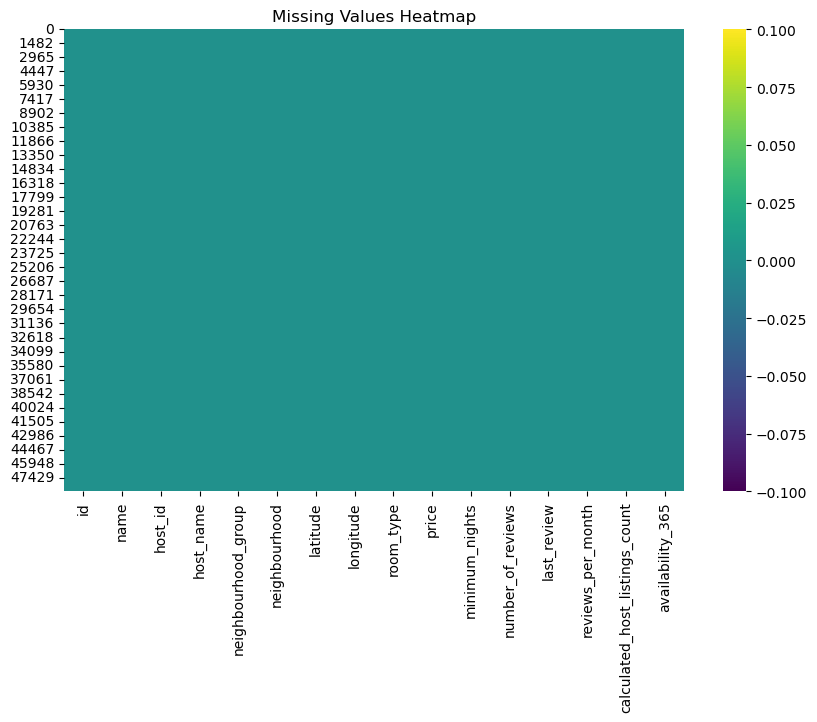

In [12]:
# Visualizing Missing Values Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=True, cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()


## What did you know about your dataset?

The Airbnb NYC 2019 dataset contains information about Airbnb listings in New York City. The dataset includes 48,895 rows and 16 columns.

Each row represents one Airbnb listing, and the columns include important features such as listing name, host ID, neighbourhood, room type, price, number of reviews, and availability.

From the dataset information, we observed that some columns such as reviews_per_month, last_review, and host_name contain missing values.

There are no duplicate values found in the dataset, which means data quality is good.

The dataset contains both numerical and categorical variables, which makes it suitable for Exploratory Data Analysis.

This dataset will help analyze pricing trends, revenue patterns, and business performance of Airbnb listings in New York City.

# Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

# Chart 1 – Listings per Neighbourhood

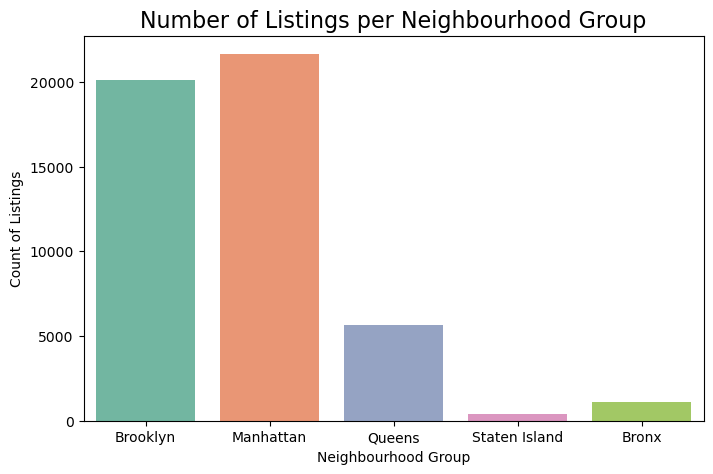

In [25]:
# Chart - 1 visualization code

plt.figure(figsize=(8,5))
sns.countplot(x='neighbourhood_group', data=df, palette='Set2')
plt.title("Number of Listings per Neighbourhood Group", fontsize=16)
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count of Listings")
plt.show()



# Chart – 1
1. Why did you pick the specific chart?

Countplot is used to show the distribution of listings across different neighbourhood groups.

2. What is/are the insight(s) found from the chart?

Manhattan and Brooklyn have the highest number of listings, while Bronx and Staten Island have the lowest.

3. Will the gained insights help creating a positive business impact?

Yes, it helps identify high-demand areas for focused marketing and pricing strategies. However, high listing concentration may lead to strong competition.

# Chart 2 – Room Type Distribution

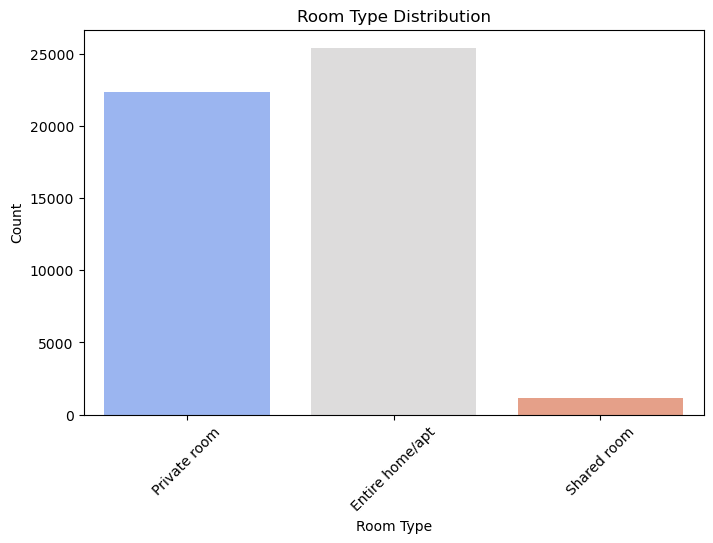

In [26]:
# Chart - 2 visualization code
plt.figure(figsize=(8,5))
sns.countplot(x='room_type', data=df, palette='coolwarm')
plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()



# Chart-2
1. Why did you pick the specific chart?

Countplot clearly shows the distribution of room types.

2. What is/are the insight(s) found from the chart?

Entire home/apartment is most preferred, followed by private rooms. Shared rooms are least preferred.

3. Will the gained insights help creating a positive business impact?

Yes, Airbnb can focus more on entire homes to increase revenue. Low demand for shared rooms may limit growth in that segment.

# Chart 3 – Price Distribution

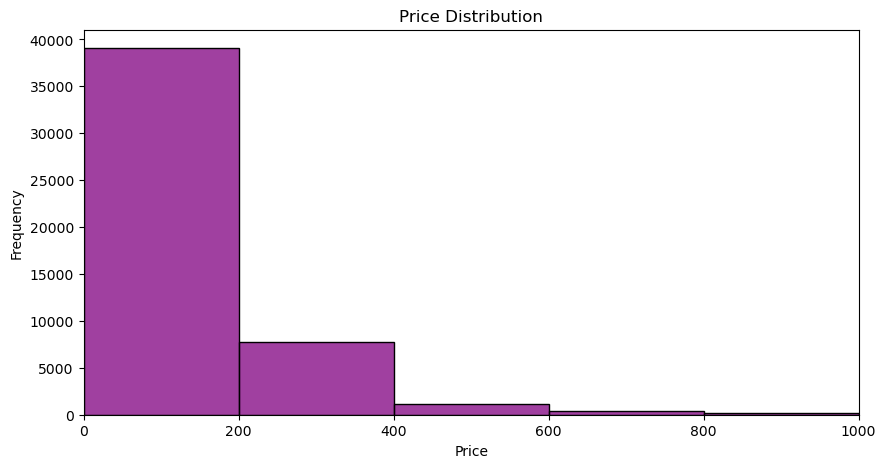

In [27]:
# Chart - 3 visualization code
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, color='purple')
plt.xlim(0,1000)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()



# Chart-3
1. Why did you pick the specific chart?

Histogram is ideal for understanding the distribution of a numerical variable like price.

2. What is/are the insight(s) found from the chart?

Most listings are priced below $300, with few high-price outliers.

3. Will the gained insights help creating a positive business impact?

Yes, it helps identify competitive pricing ranges. Extremely high prices may reduce bookings and negatively impact growth.

# Chart 4 – Number of Reviews Distribution

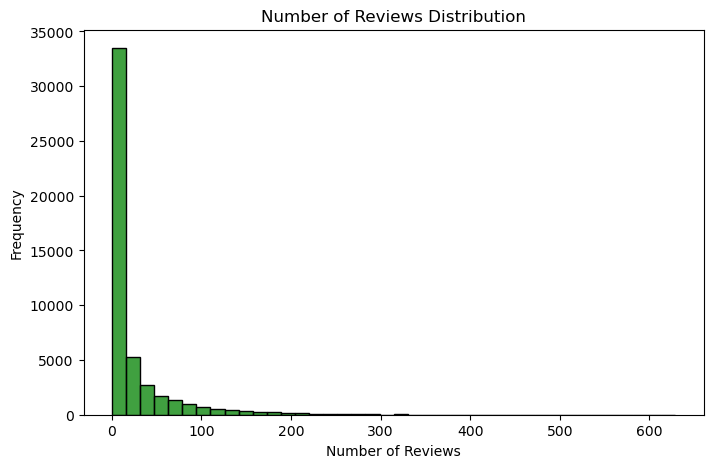

In [30]:
# Chart - 4 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df['number_of_reviews'], bins=40, color='green')
plt.title("Number of Reviews Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()



# Chart-4
1. Why did you pick the specific chart?

Histogram helps understand how reviews are distributed across listings.

2. What is/are the insight(s) found from the chart?

Most listings have fewer reviews, while only a few have very high reviews.

3. Will the gained insights help creating a positive business impact?

Yes, Airbnb can support low-review listings through promotions. Listings with very few reviews may struggle to attract customers.

# Chart 5 – Availability Distribution

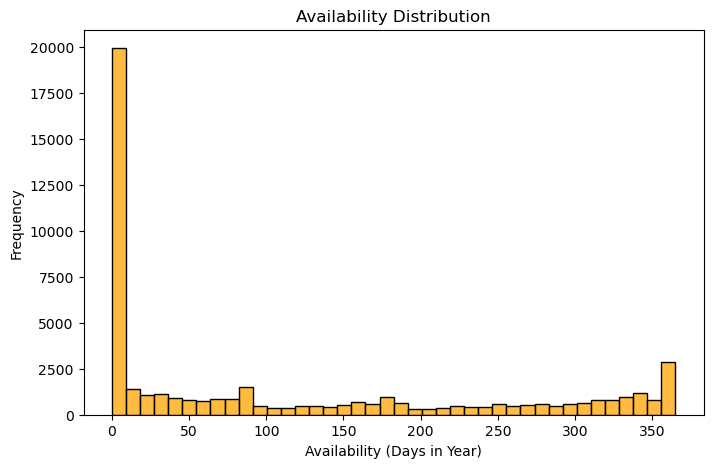

In [33]:
# Chart - 5 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df['availability_365'], bins=40, color='orange')
plt.title("Availability Distribution")
plt.xlabel("Availability (Days in Year)")
plt.ylabel("Frequency")
plt.show()



# Chart -5
1. Why did you pick the specific chart?

Histogram is useful to analyze distribution of availability over the year.

2. What is/are the insight(s) found from the chart?

Many listings are available for a large number of days, while some have limited availability.

3. Will the gained insights help creating a positive business impact?

Yes, high availability may indicate lower booking rates. Airbnb can improve marketing for such listings. Low availability may indicate high demand.


# Chart 6 – Average Price by Neighbourhood

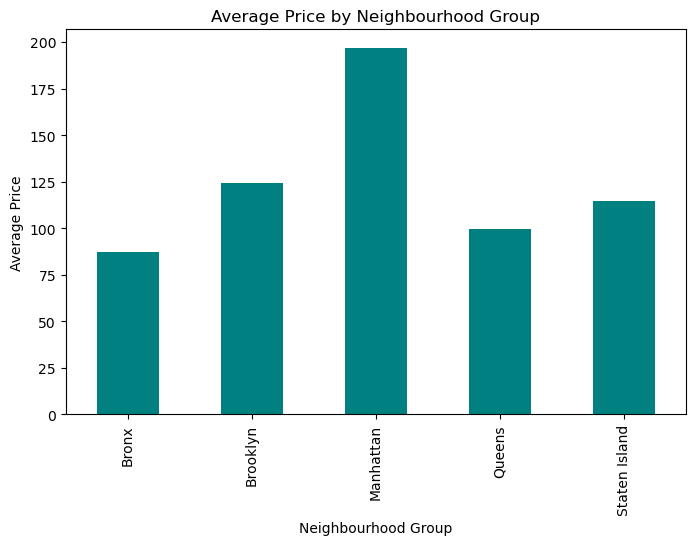

In [29]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))
df.groupby('neighbourhood_group')['price'].mean().plot(kind='bar', color='teal')
plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.show()


# Chart-6
1. Why did you pick the specific chart?

Bar chart is suitable to compare average prices across different neighbourhood groups.

2. What is/are the insight(s) found from the chart?

Manhattan has the highest average price, followed by Brooklyn. Bronx and Staten Island have lower average prices.

3. Will the gained insights help creating a positive business impact?

Yes, Airbnb can apply premium pricing strategies in Manhattan. Lower-priced areas can attract budget travelers. Very high pricing may reduce bookings if not balanced properly.

# Chart – 7 : Price vs Room Type

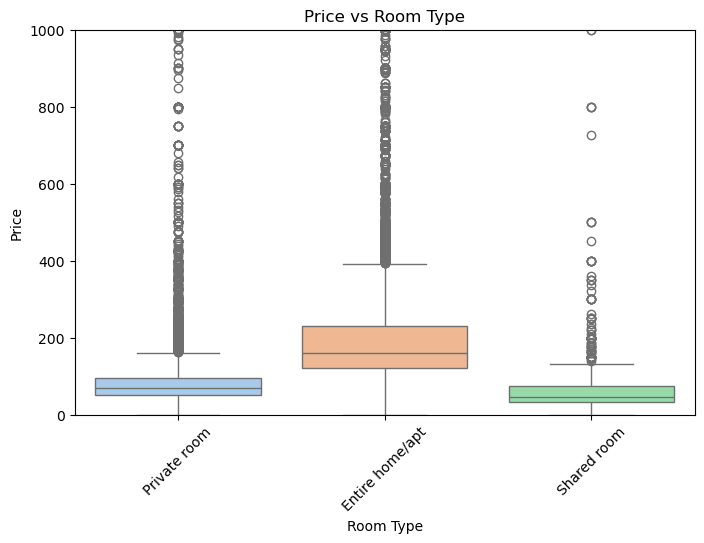

In [35]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df, palette='pastel')
plt.ylim(0,1000)
plt.title("Price vs Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()


# Chart-7
1. Why did you pick the specific chart?

Boxplot is best to compare price distribution across different room types and detect outliers.

2. What is/are the insight(s) found from the chart?

Entire home/apartment has the highest median price. Shared rooms have the lowest prices.

3. Will the gained insights help creating a positive business impact?

Yes, Airbnb can focus on entire homes to maximize revenue. Very high price outliers may reduce booking rates.

# Chart – 8 : Price vs Neighbourhood Group

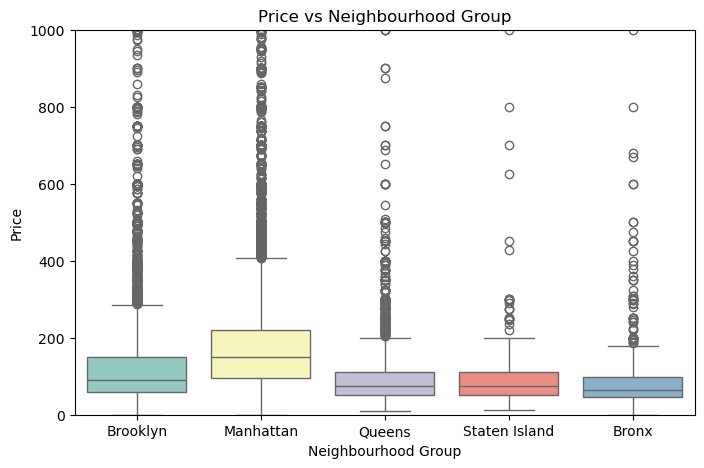

In [36]:
# Chart - 8 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=df, palette='Set3')
plt.ylim(0,1000)
plt.title("Price vs Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")
plt.show()


# Chart-8
1. Why did you pick the specific chart?

Boxplot helps compare price spread and median price across neighbourhood groups.

2. What is/are the insight(s) found from the chart?

Manhattan has the highest price variation and median price. Bronx has the lowest pricing.

3. Will the gained insights help creating a positive business impact?

Yes, premium pricing can be applied in Manhattan. Lower-price areas can target budget customers.

# Chart-9 Reviews vs Price

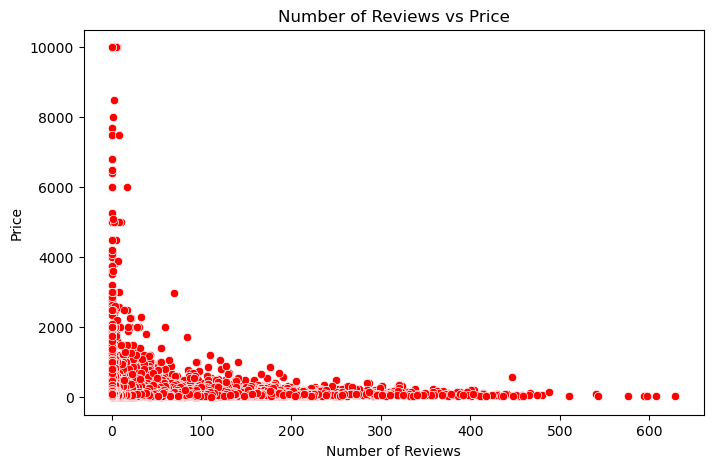

In [37]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(x='number_of_reviews', y='price', data=df, color='red')
plt.title("Number of Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()


# Chart-9
1. Why did you pick the specific chart?

Scatterplot is suitable to analyze the relationship between two numerical variables.

2. What is/are the insight(s) found from the chart?

There is no strong direct relationship between price and number of reviews. Some low-price listings have many reviews.

3. Will the gained insights help creating a positive business impact?

Yes, competitive pricing may increase reviews and bookings. Overpriced listings may struggle to gain reviews.

# Chart – 10 : Top 10 Hosts by Number of Listings

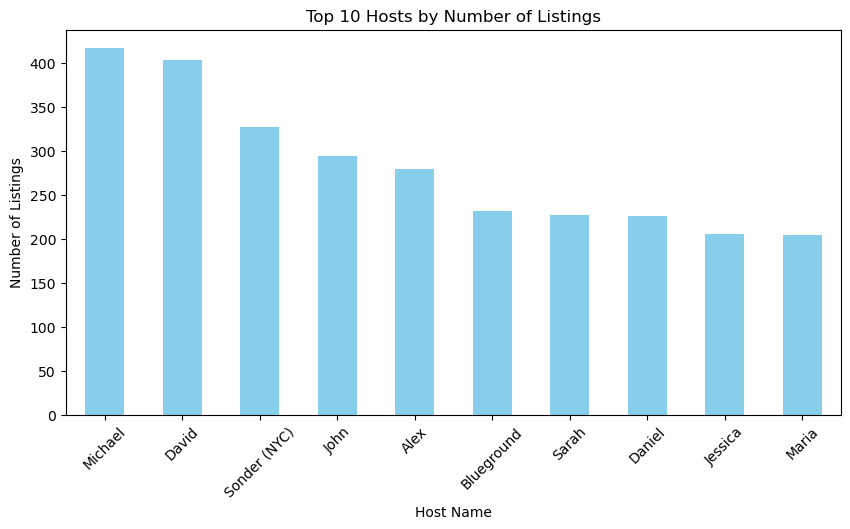

In [38]:
# Chart - 10 visualization code
plt.figure(figsize=(10,5))
df['host_name'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Host Name")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()


# Chart-10
1. Why did you pick the specific chart?

Bar chart is best to compare top hosts based on number of listings.

2. What is/are the insight(s) found from the chart?

A small number of hosts manage multiple listings, indicating commercial hosting activity.

3. Will the gained insights help creating a positive business impact?

Yes, Airbnb can create special policies for multi-property hosts. However, too many listings under one host may reduce platform fairness and affect small hosts.

# Chart – 11 : Correlation Heatmap

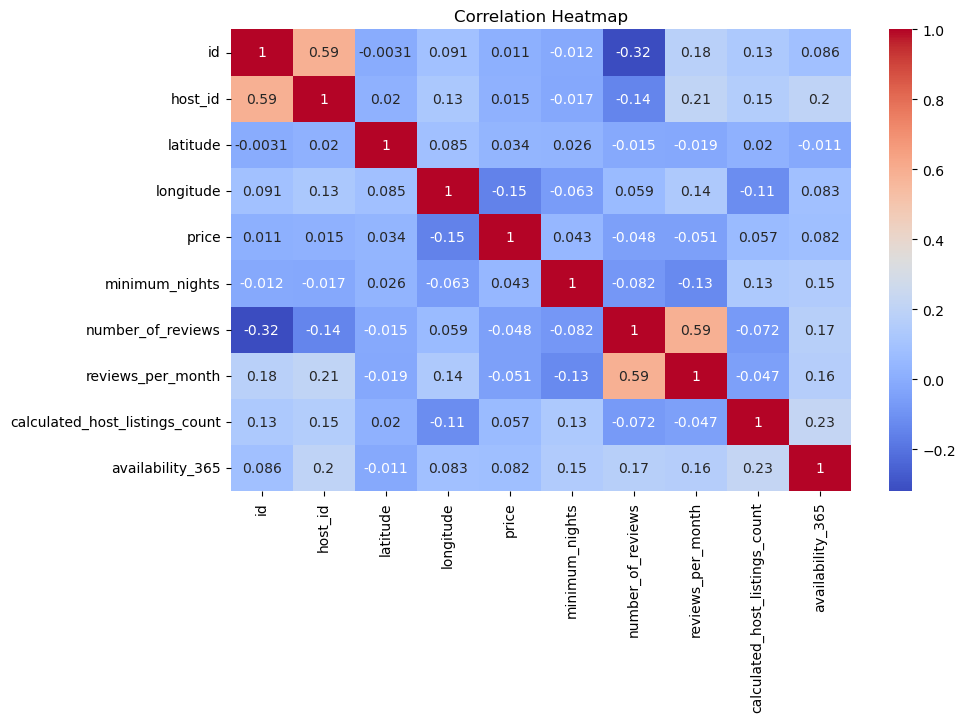

In [40]:
# Chart - 11 visualization code
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, 
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



# Chart-11
1. Why did you pick the specific chart?

Heatmap is used to clearly visualize the correlation between numerical variables in the dataset.

2. What is/are the insight(s) found from the chart?

The heatmap shows that price has weak correlation with number_of_reviews and availability_365. There is no strong linear relationship between most variables.

3. Will the gained insights help creating a positive business impact?

Yes, it indicates that pricing depends on multiple factors rather than just reviews or availability. This insight supports the need for dynamic and data-driven pricing strategies to maximize revenue.

# Chart – 12 : Minimum Nights Distribution


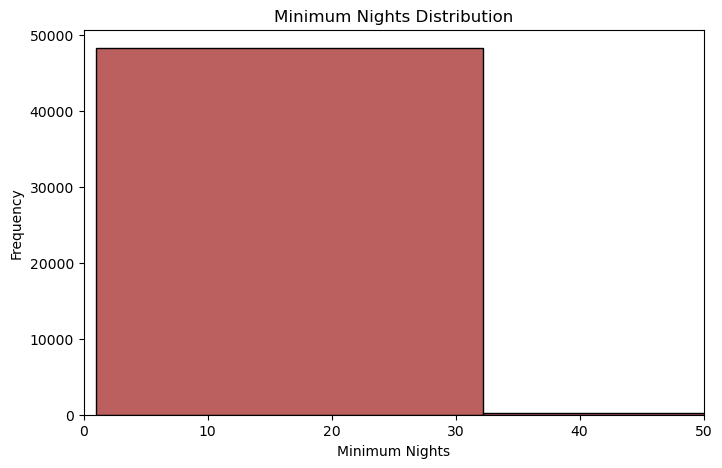

In [42]:
# Chart - 12 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df['minimum_nights'], bins=40, color='brown')
plt.xlim(0,50)
plt.title("Minimum Nights Distribution")
plt.xlabel("Minimum Nights")
plt.ylabel("Frequency")
plt.show()


# Chart-12
1. Why did you pick the specific chart?

Histogram is useful to understand the distribution of minimum stay requirements.

2. What is/are the insight(s) found from the chart?

Most listings have low minimum night requirements (1–5 nights). Few listings require long stays.

3. Will the gained insights help creating a positive business impact?

Yes, flexible minimum night policies attract more customers. High minimum stay requirements may reduce bookings.

# Chart – 13 : Estimated Revenue by Neighbourhood

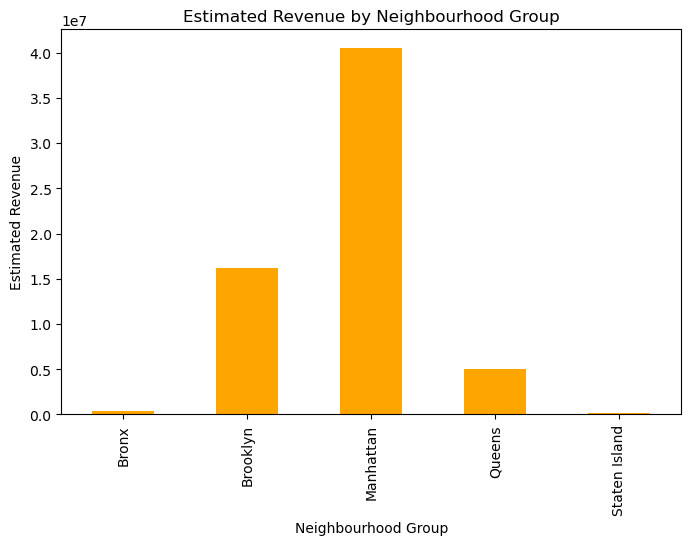

In [44]:
# Create estimated revenue column
df['estimated_revenue'] = df['price'] * df['minimum_nights']

# Chart - 13 visualization code
plt.figure(figsize=(8,5))
df.groupby('neighbourhood_group')['estimated_revenue'].sum().plot(kind='bar', color='orange')
plt.title("Estimated Revenue by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Estimated Revenue")
plt.show()


# Chart-13
1. Why did you pick the specific chart?

Bar chart is ideal to compare total estimated revenue across neighbourhood groups.

2. What is/are the insight(s) found from the chart?

Manhattan generates the highest estimated revenue, followed by Brooklyn. Other boroughs contribute significantly less.

3. Will the gained insights help creating a positive business impact?

Yes, it helps Airbnb focus premium strategies in high-revenue areas. Lower revenue areas can be targeted for growth initiatives.

# Chart – 14 : Detailed Correlation Heatmap

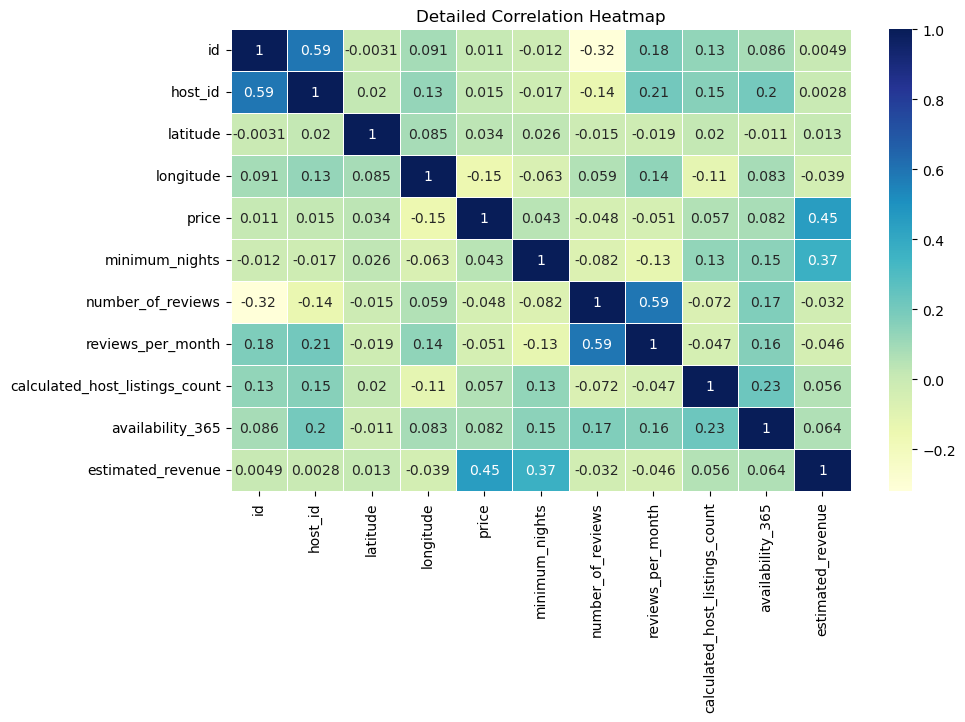

In [45]:
# Chart - 14 visualization code
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='YlGnBu',
            linewidths=0.5)
plt.title("Detailed Correlation Heatmap")
plt.show()


# Chart-14
1. Why did you pick the specific chart?

Heatmap provides a detailed overview of relationships among all numerical variables.

2. What is/are the insight(s) found from the chart?

Most variables show weak correlations. Price is not strongly dependent on reviews or availability alone, indicating multiple influencing factors.

3. Will the gained insights help creating a positive business impact?

Yes, it supports dynamic pricing models instead of relying on a single factor. No strong negative correlation suggests stable relationships among variables.

# Chart – 15 : Pairplot Analysis

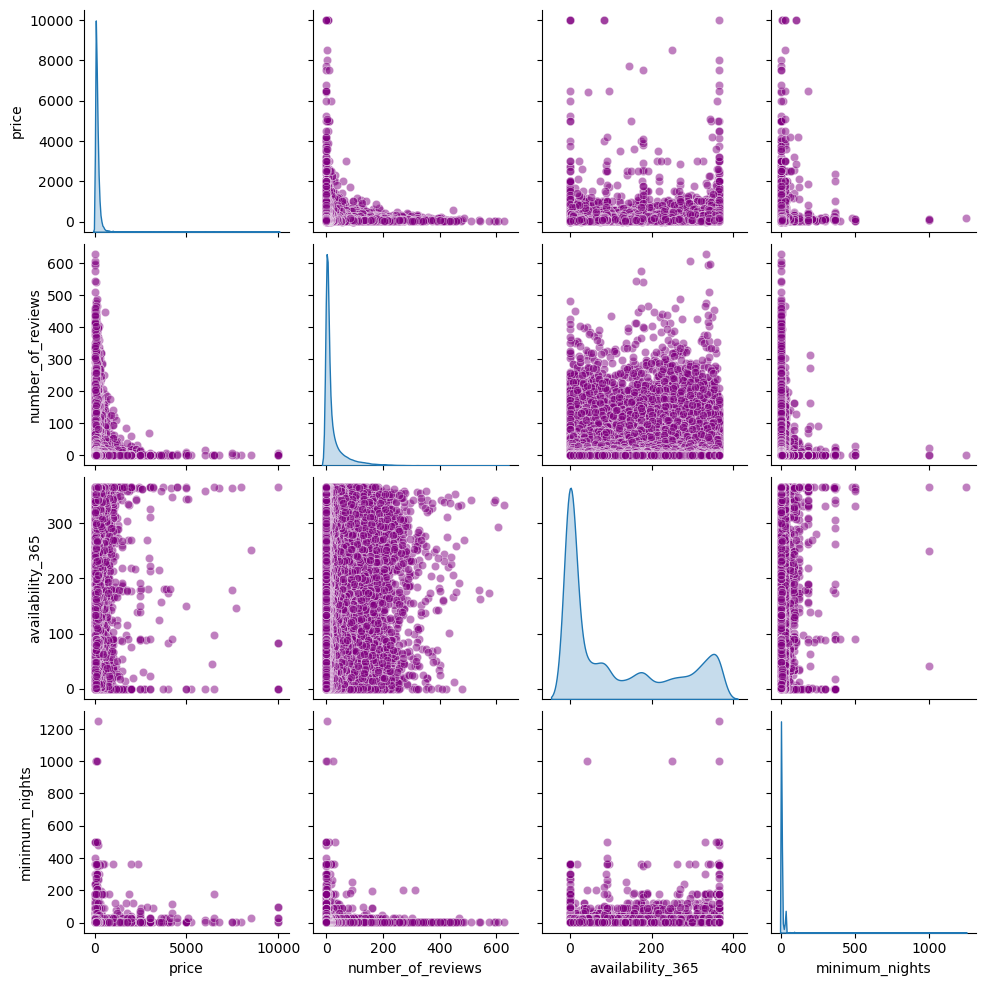

In [46]:
# Chart - 15 visualization code
sns.pairplot(df[['price','number_of_reviews','availability_365','minimum_nights']],
             diag_kind='kde',
             plot_kws={'alpha':0.5, 'color':'purple'})
plt.show()


# Chart-15
1. Why did you pick the specific chart?

Pairplot helps visualize relationships between multiple numerical variables simultaneously.

2. What is/are the insight(s) found from the chart?

It confirms weak relationships between price and other variables. Some clusters indicate popular pricing ranges.

3. Will the gained insights help creating a positive business impact?

Yes, it helps understand pricing patterns and customer behavior. No strong linear trends suggest pricing strategy should consider multiple combined factors.

# Solution to Business Objective:


To achieve the business objectives, the following strategies are recommended:

## Focus on High-Demand Areas
Manhattan and Brooklyn show the highest listing concentration and revenue potential. Airbnb should apply premium pricing strategies and targeted marketing campaigns in these areas to maximize profitability.

## Promote Growth in Low-Listing Areas
Bronx and Staten Island have fewer listings. Airbnb can introduce promotional offers, host incentives, and awareness campaigns to encourage more hosts and attract customers in these regions.

## Optimize Pricing Strategy
Since price does not strongly depend on reviews or availability alone, Airbnb should implement dynamic pricing models based on multiple factors such as demand trends, seasonality, and neighborhood performance.

## Encourage Entire Home Listings
Entire home/apartment listings are most preferred by customers. Airbnb can promote such listings to increase booking rates and overall revenue.

## Support Low-Performing Hosts
Many listings have low reviews. Airbnb can provide visibility boosts, discounts, or host training programs to help improve their performance.

## Improve Occupancy Management
Listings with very high availability may indicate low bookings. Targeted marketing and competitive pricing can help improve occupancy rates.

## Final Suggestion

By focusing on high-revenue neighborhoods, implementing dynamic pricing, supporting underperforming areas, and optimizing listing strategies, Airbnb can enhance customer satisfaction, increase bookings, and achieve sustainable business growth.

# Conclusion:

In this project, Exploratory Data Analysis (EDA) was performed on the Airbnb NYC 2019 dataset to understand pricing trends, customer preferences, host behavior, and neighborhood performance. The analysis revealed that Manhattan and Brooklyn dominate the Airbnb market in terms of listings and revenue potential. Entire home/apartment listings are the most preferred accommodation type, indicating that customers value privacy and comfort.

The pricing analysis showed that most listings fall within a competitive range below $300, with a few high-price outliers. Correlation analysis indicated that price does not have a strong linear relationship with reviews or availability, suggesting that multiple factors influence pricing decisions. Additionally, some hosts manage multiple listings, reflecting commercial hosting activity on the platform.

The insights derived from this analysis can help Airbnb optimize pricing strategies, improve marketing focus, support low-performing areas, and enhance overall revenue generation. By leveraging data-driven decision-making, Airbnb can strengthen its competitive position and achieve sustainable growth in the New York City market.

Overall, this project demonstrates how structured data analysis and visualization can provide meaningful business insights and support strategic planning.